<a href="https://colab.research.google.com/github/Shakada26/carisurg-portfolio/blob/main/baseline_model_triage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mercer General Hospital - Baseline Triage Model (Logistic Regression & Decision Tree)

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    recall_score,
    f1_score,
)

RANDOM_STATE = 42

In [3]:
from google.colab import files
uploaded = files.upload()  # select triage_cleaned_v1.csv when prompted

Saving yaleemmlc_admissionprediction_triage.csv.bz2 to yaleemmlc_admissionprediction_triage.csv (1).bz2


In [5]:
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name, compression='bz2')
print(f"Loaded {df.shape[0]} patients, {df.shape[1]} columns.")
df.head()

Loaded 55121 patients, 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
TARGET = "esi"  # confirm this matches your column name exactly

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp",
          "triage_vital_rr", "triage_vital_o2", "triage_vital_temp",
          "triage_glucose"]

DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]

ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

LEAKAGE = ["disposition", "previousdispo"]  # only known AFTER triage — never use these

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]
FEATURES = [c for c in FEATURES if pd.api.types.is_numeric_dtype(df[c])]

X = df[FEATURES]
y = df[TARGET]

print(f"Predicting '{TARGET}' using {len(FEATURES)} features:")
print(FEATURES)

Predicting 'esi' using 209 features:
['Unnamed: 0', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'triage_glucose', 'cc_abdominalcramping', 'cc_abdominaldistention', 'cc_abdominalpain', 'cc_abdominalpainpregnant', 'cc_abnormallab', 'cc_abscess', 'cc_addictionproblem', 'cc_agitation', 'cc_alcoholintoxication', 'cc_alcoholproblem', 'cc_allergicreaction', 'cc_alteredmentalstatus', 'cc_animalbite', 'cc_ankleinjury', 'cc_anklepain', 'cc_anxiety', 'cc_arminjury', 'cc_armpain', 'cc_armswelling', 'cc_assaultvictim', 'cc_asthma', 'cc_backpain', 'cc_bleeding/bruising', 'cc_blurredvision', 'cc_bodyfluidexposure', 'cc_breastpain', 'cc_breathingdifficulty', 'cc_breathingproblem', 'cc_burn', 'cc_cardiacarrest', 'cc_cellulitis', 'cc_chestpain', 'cc_chesttightness', 'cc_chills', 'cc_coldlikesymptoms', 'cc_confusion', 'cc_conjunctivitis', 'cc_constipation', 'cc_cough', 'cc_cyst', 'cc_decreasedbloodsugar-sy

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])
print("\nTest set ESI proportions:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1))

Training patients: 44096
Testing patients:  11025

Test set ESI proportions:
esi
1.0     0.1
2.0    32.5
3.0    49.0
4.0    16.1
5.0     2.2
Name: proportion, dtype: float64


In [9]:
# Floor to beat: guesses ESI levels randomly, matching training proportions
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

# Logistic Regression needs scaled features (sensitive to feature magnitude)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
pred_logreg = logreg.predict(X_test_scaled)

# Decision Tree — does NOT need scaling; max_depth=5 keeps it interpretable
tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

print("All models trained. Quick accuracy check:")
print(f"  Dummy:               {accuracy_score(y_test, pred_dummy):.3f}")
print(f"  Logistic Regression: {accuracy_score(y_test, pred_logreg):.3f}")
print(f"  Decision Tree:       {accuracy_score(y_test, pred_tree):.3f}")

All models trained. Quick accuracy check:
  Dummy:               0.375
  Logistic Regression: 0.667
  Decision Tree:       0.556


In [10]:
def per_class_report(y_true, y_pred, model_name):
    report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).transpose().round(3)
    print(f"\n===== {model_name} =====")
    display(report_df)
    return report_df

logreg_report = per_class_report(y_test, pred_logreg, "Logistic Regression")
tree_report = per_class_report(y_test, pred_tree, "Decision Tree")


===== Logistic Regression =====


,precision,recall,f1-score,support
1.0,0.444,0.250,0.320,16.000
2.0,0.716,0.608,0.658,3585.000
3.0,0.660,0.758,0.706,5402.000
4.0,0.610,0.588,0.599,1779.000
5.0,0.509,0.119,0.193,243.000
accuracy,0.667,0.667,0.667,0.667
macro avg,0.588,0.465,0.495,11025.000
weighted avg,0.667,0.667,0.661,11025.000



===== Decision Tree =====


,precision,recall,f1-score,support
1.0,0.000,0.000,0.000,16.000
2.0,0.796,0.265,0.398,3585.000
3.0,0.527,0.959,0.680,5402.000
4.0,0.000,0.000,0.000,1779.000
5.0,0.000,0.000,0.000,243.000
accuracy,0.556,0.556,0.556,0.556
macro avg,0.265,0.245,0.216,11025.000
weighted avg,0.517,0.556,0.463,11025.000


In [11]:
esi1 = 1  # adjust if your ESI-1 label is coded differently

for name, preds in [("Dummy", pred_dummy), ("Logistic Regression", pred_logreg), ("Decision Tree", pred_tree)]:
    r = recall_score(y_test, preds, labels=[esi1], average=None, zero_division=0)[0]
    print(f"{name:22s} recall on ESI 1: {r:.3f}")

Dummy                  recall on ESI 1: 0.000
Logistic Regression    recall on ESI 1: 0.250
Decision Tree          recall on ESI 1: 0.000


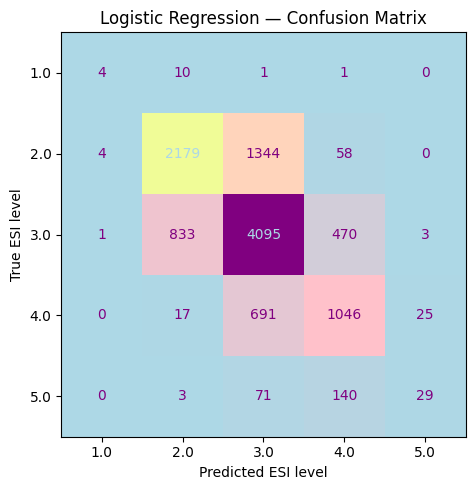

In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap # Added this import

os.makedirs("docs", exist_ok=True)  # in Colab this creates a local 'docs' folder

fig, ax = plt.subplots(figsize=(6, 5))

# Define the colors requested by the user: light blue, pink, yellow, green, purple
# Arranged to create a visually distinct gradient from light to darker shades
colors_for_gradient = ['#ADD8E6', '#FFC0CB', '#FFFF99', '#90EE90', '#800080'] # Light Blue, Pink, Light Yellow, Light Green, Purple
custom_cmap = LinearSegmentedColormap.from_list("user_custom_cmap", colors_for_gradient)

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_logreg,
    labels=sorted(y_test.unique()),  # ensures axis shows real ESI values, e.g. 1-5
    ax=ax,
    colorbar=False,
    cmap=custom_cmap, # Using the custom colormap
)
ax.set_xlabel("Predicted ESI level")
ax.set_ylabel("True ESI level")
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig("docs/confusion_matrix_logreg.png", dpi=150, bbox_inches="tight")
plt.show()